In [50]:
# Einfluss von Wetterbedingungen auf Flugverspätungen
## Flughafen Wien (Vienna International Airport) Gruppe 9

In [51]:
# 1. Imports & Setup

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pymongo import MongoClient

# Für konsistente und gut lesbare Visualisierungen
sns.set(style="whitegrid")

In [52]:
# 2. MongoDB-Verbindung herstellen

client = MongoClient('mongodb://localhost:27017/')
db = client['fluege_wetter']
flights_collection = db['flights']
weather_collection = db['weather']

# Vorhandene Collections prüfen
print("Collections in der Datenbank:", db.list_collection_names())

Collections in der Datenbank: ['weather', 'flights']


In [53]:
# 3. Daten laden & mergen

# Flugdaten und Wetterdaten laden
flights = pd.read_csv('all_pre_departure_delays_2025.csv')
weather = pd.read_csv('weather.csv', decimal=',')

# Zeitspalten in echtes Datumsformat umwandeln
flights['scheduled_departure'] = pd.to_datetime(flights['FLT_DATE'])
weather['datetime'] = pd.to_datetime(weather['date'])

# Merge der Flugdaten mit den Wetterdaten anhand des Abflugdatums
df_merged = pd.merge(
    flights[flights['APT_ICAO'] == 'LOWW'],  # Nur Flüge am Flughafen Wien
    weather,
    left_on='scheduled_departure',
    right_on='datetime',
    how='left'
)

In [54]:
# 4. Daten in MongoDB importieren

# Alte Daten löschen (optional, falls schon Daten vorhanden)
flights_collection.delete_many({})
weather_collection.delete_many({})

# Flugdaten
flights_collection.insert_many(flights.to_dict('records'))

# Wetterdaten
weather_collection.insert_many(weather.to_dict('records'))

print("Daten erfolgreich in MongoDB importiert!")

Daten erfolgreich in MongoDB importiert!


In [55]:
# 5. Daten aus MongoDB abrufen

# Flugdaten
df_flights = pd.DataFrame(list(flights_collection.find()))

# Wetterdaten
df_weather = pd.DataFrame(list(weather_collection.find()))

# Erste 5 Zeilen prüfen
print("Flugdaten:")
print(df_flights.head())

print("\nWetterdaten:")
print(df_weather.head())

Flugdaten:
                        _id  YEAR  MONTH_NUM MONTH_MON    FLT_DATE APT_ICAO  \
0  69e8e580d6cc8b284a9ea3f9  2025          1       JAN  2025-01-01     LATI   
1  69e8e580d6cc8b284a9ea3fa  2025          1       JAN  2025-01-01     UDYZ   
2  69e8e580d6cc8b284a9ea3fb  2025          1       JAN  2025-01-01     LOWG   
3  69e8e580d6cc8b284a9ea3fc  2025          1       JAN  2025-01-01     LOWI   
4  69e8e580d6cc8b284a9ea3fd  2025          1       JAN  2025-01-01     LOWK   

     APT_NAME STATE_NAME  FLT_DEP_1  FLT_DEP_IFR_2  DLY_ALL_PRE_2  \
0      Tirana    Albania         64            NaN            NaN   
1     Yerevan    Armenia         57            NaN            NaN   
2        Graz    Austria          7            NaN            NaN   
3   Innsbruck    Austria         24            NaN            NaN   
4  Klagenfurt    Austria          2            NaN            NaN   

  scheduled_departure  
0          2025-01-01  
1          2025-01-01  
2          2025-01-01  
3  

In [56]:
# 6. Flugdaten & Wetterdaten zusammenführen

# Merge der Flugdaten mit Wetterdaten anhand des Abflugdatums
df_merged = pd.merge(
    df_flights,
    df_weather,
    left_on='scheduled_departure',  # Flugdaten
    right_on='datetime',  # Wetterdaten
    how='left'  # Left Join: alle Flüge behalten, Wetterdaten ergänzen
)

# Ergebnis prüfen
print("Zusammengeführte Daten:")
print(df_merged.head())

Zusammengeführte Daten:
                      _id_x  YEAR  MONTH_NUM MONTH_MON    FLT_DATE APT_ICAO  \
0  69e8e580d6cc8b284a9ea3f9  2025          1       JAN  2025-01-01     LATI   
1  69e8e580d6cc8b284a9ea3fa  2025          1       JAN  2025-01-01     UDYZ   
2  69e8e580d6cc8b284a9ea3fb  2025          1       JAN  2025-01-01     LOWG   
3  69e8e580d6cc8b284a9ea3fc  2025          1       JAN  2025-01-01     LOWI   
4  69e8e580d6cc8b284a9ea3fd  2025          1       JAN  2025-01-01     LOWK   

     APT_NAME STATE_NAME  FLT_DEP_1  FLT_DEP_IFR_2  ...  tmin tmax prcp snow  \
0      Tirana    Albania         64            NaN  ...  -4.0 -2.8  0.0  NaN   
1     Yerevan    Armenia         57            NaN  ...  -4.0 -2.8  0.0  NaN   
2        Graz    Austria          7            NaN  ...  -4.0 -2.8  0.0  NaN   
3   Innsbruck    Austria         24            NaN  ...  -4.0 -2.8  0.0  NaN   
4  Klagenfurt    Austria          2            NaN  ...  -4.0 -2.8  0.0  NaN   

   wdir  wspd  wpgt 

Durchschnittliche Verspätung nach Temperaturbereich:
temp_range
(-10, 0]    61.506572
(0, 10]     66.588876
(10, 20]    79.858631
(20, 30]    84.492580
Name: FLT_DEP_1, dtype: float64


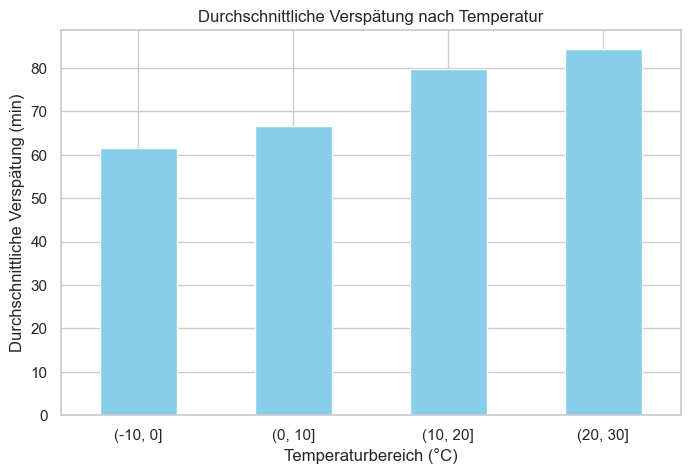

In [57]:
# 7. Analyse: Durchschnittliche Verspätung nach Temperatur

# Temperaturbereiche definieren (°C)
temp_bins = [-10, 0, 10, 20, 30]
df_merged['temp_range'] = pd.cut(df_merged['tavg'], bins=temp_bins)

# Durchschnittliche Verspätung pro Temperaturbereich berechnen
avg_delay = df_merged.groupby('temp_range', observed=True)['FLT_DEP_1'].mean()

print("Durchschnittliche Verspätung nach Temperaturbereich:")
print(avg_delay)

# Visualisierung Balkendiagramm

avg_delay.plot(kind='bar', figsize=(8,5), color='skyblue')
plt.xlabel("Temperaturbereich (°C)")
plt.ylabel("Durchschnittliche Verspätung (min)")
plt.title("Durchschnittliche Verspätung nach Temperatur")
plt.xticks(rotation=0)
plt.show()

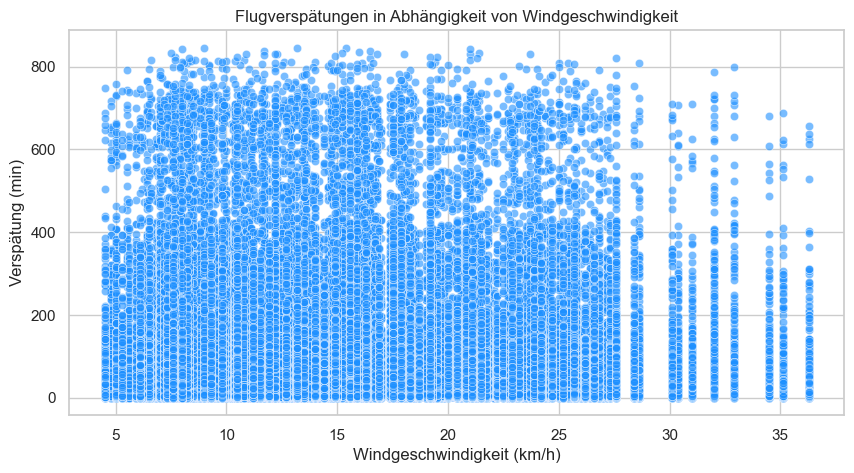

In [58]:
# 8. Analyse: Verspätung vs. Windgeschwindigkeit

# Scatterplot: Verspätung in Abhängigkeit von Windgeschwindigkeit
plt.figure(figsize=(10,5))
sns.scatterplot(
    x='wspd',
    y='FLT_DEP_1',
    data=df_merged,
    color='dodgerblue',
    alpha=0.6
)

# Achsenbeschriftungen und Titel
plt.xlabel("Windgeschwindigkeit (km/h)")
plt.ylabel("Verspätung (min)")
plt.title("Flugverspätungen in Abhängigkeit von Windgeschwindigkeit")
plt.show()

Aggregierte Daten nach Temperatur:
    tavg  avg_delay
0   -4.0  61.744021
1   -3.0  57.846318
2   -2.0  62.399935
3   -1.0  61.552674
4    0.0  62.976007
5    1.0  62.533001
6    2.0  65.160451
7    3.0  64.895384
8    4.0  62.831956
9    5.0  68.118868
10   6.0  63.445529
11   7.0  70.819250
12   8.0  68.383148
13   9.0  75.096985
14  10.0  74.287438
15  11.0  74.859979
16  12.0  77.786764
17  13.0  78.488859
18  14.0  77.620338
19  15.0  78.845943
20  16.0  82.276025
21  17.0  83.028150
22  18.0  83.405036
23  19.0  84.854634
24  20.0  84.131603
25  21.0  84.573321
26  22.0  84.576869
27  23.0  85.217489
28  24.0  85.087470
29  25.0  84.821926
30  26.0  84.809176
31  27.0  82.346395


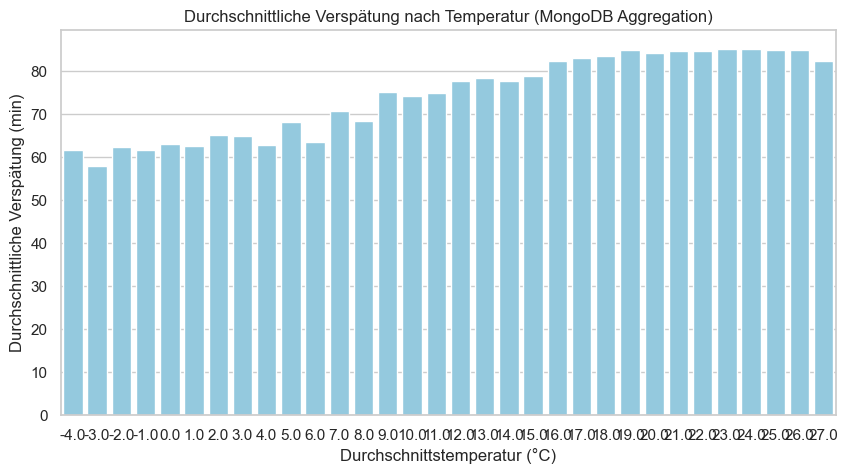

In [59]:
# 9. Analyse: Durchschnittliche Verspätung nach Temperatur

# Pipeline definieren für Aggregation in MongoDB
pipeline_temp = [
    {
        "$lookup": {  # Verknüpfung mit Wetter-Collection
            "from": "weather",
            "localField": "scheduled_departure",
            "foreignField": "datetime",
            "as": "weather_info"
        }
    },
    {"$unwind": "$weather_info"},  # Array auflösen, jedes Wetterobjekt wird zur Zeile
    {
        "$group": {  # Gruppieren nach abgerundeter Durchschnittstemperatur
            "_id": {"tavg": {"$floor": "$weather_info.tavg"}},
            "avg_delay": {"$avg": "$FLT_DEP_1"}  # Durchschnittliche Verspätung berechnen
        }
    },
    {"$sort": {"_id.tavg": 1}}  # Aufsteigend nach Temperatur sortieren
]

# Aggregation ausführen
result = list(flights_collection.aggregate(pipeline_temp))

# In DataFrame umwandeln
df_agg_temp = pd.DataFrame(result)
df_agg_temp.rename(columns={"_id": "tavg"}, inplace=True)
df_agg_temp["tavg"] = df_agg_temp["tavg"].apply(lambda x: x["tavg"])  # Wert extrahieren

# Ergebnis prüfen
print("Aggregierte Daten nach Temperatur:")
print(df_agg_temp)

# Visualisierung: Balkendiagramm
plt.figure(figsize=(10,5))
sns.barplot(x="tavg", y="avg_delay", data=df_agg_temp, color='skyblue')
plt.xlabel("Durchschnittstemperatur (°C)")
plt.ylabel("Durchschnittliche Verspätung (min)")
plt.title("Durchschnittliche Verspätung nach Temperatur (MongoDB Aggregation)")
plt.show()

Aggregierte Daten nach Niederschlag:
   prcp  avg_delay
0   NaN  64.391421
1   0.0  74.741057
2   1.0  78.097324
3   2.0  75.807531
4   3.0  77.878049


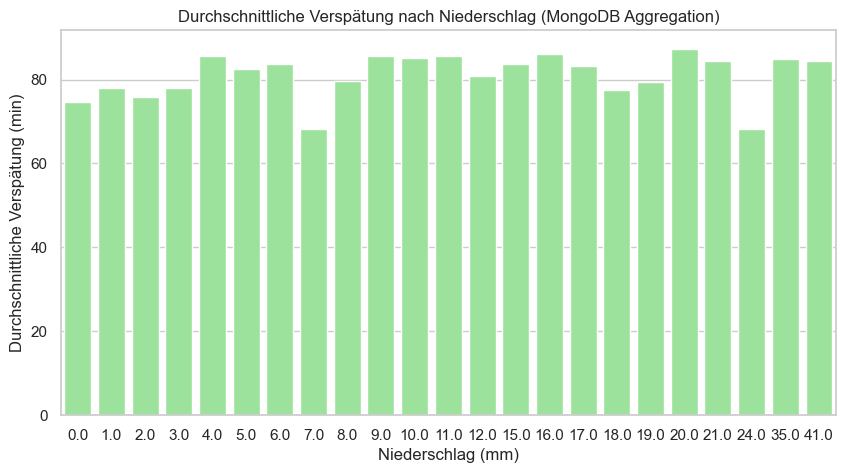

In [60]:
# 10. Analyse: Durchschnittliche Verspätung nach Niederschlag

# Pipeline definieren für Aggregation in MongoDB (Niederschlag)
pipeline_prcp = [
    {
        "$lookup": {  # Verknüpfung mit Wetter-Collection
            "from": "weather",
            "localField": "scheduled_departure",
            "foreignField": "datetime",
            "as": "weather_info"
        }
    },
    {"$unwind": "$weather_info"},  # Array auflösen, jedes Wetterobjekt wird zur Zeile
    {
        "$group": {  # Gruppieren nach abgerundetem Niederschlag
            "_id": {"prcp": {"$floor": "$weather_info.prcp"}},
            "avg_delay": {"$avg": "$FLT_DEP_1"}  # Durchschnittliche Verspätung
        }
    },
    {"$sort": {"_id.prcp": 1}}  # Aufsteigend nach Niederschlag sortieren
]

# Aggregation ausführen
result_prcp = list(flights_collection.aggregate(pipeline_prcp))

# In DataFrame umwandeln
df_prcp = pd.DataFrame(result_prcp)
df_prcp.rename(columns={"_id": "prcp"}, inplace=True)
df_prcp["prcp"] = df_prcp["prcp"].apply(lambda x: x["prcp"])  # Wert extrahieren

# Ergebnis prüfen
print("Aggregierte Daten nach Niederschlag:")
print(df_prcp.head())

# Visualisierung: Balkendiagramm
plt.figure(figsize=(10,5))
sns.barplot(x="prcp", y="avg_delay", data=df_prcp, color='lightgreen')
plt.xlabel("Niederschlag (mm)")
plt.ylabel("Durchschnittliche Verspätung (min)")
plt.title("Durchschnittliche Verspätung nach Niederschlag (MongoDB Aggregation)")
plt.show()

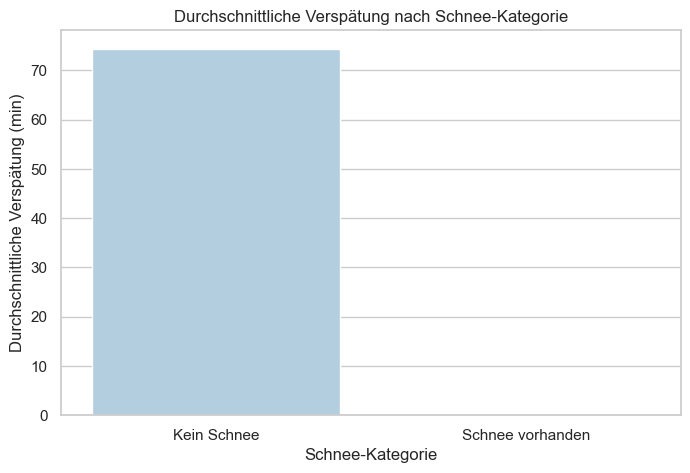

In [61]:
# 11. Analyse: Durchschnittliche Verspätung nach Schnee-Kategorie

# Schnee NaN → 0 setzen
df_merged['snow'] = df_merged['snow'].fillna(0)

# Schnee-Kategorisierung
df_merged['snow_category'] = df_merged['snow'].apply(lambda x: 'Kein Schnee' if x == 0 else 'Schnee vorhanden')

# Durchschnittliche Verspätung für jede Schneekategorie berechnen
avg_delay_snow = df_merged.groupby('snow_category')['FLT_DEP_1'].mean().reset_index()

# Sicherstellen, dass beide Kategorien immer vorhanden sind, auch wenn sie keine Flüge haben
all_categories = ['Kein Schnee', 'Schnee vorhanden']
avg_delay_snow = avg_delay_snow.set_index('snow_category').reindex(all_categories).reset_index()

# Balkendiagramm erstellen
plt.figure(figsize=(8, 5))
sns.barplot(x='snow_category', y='FLT_DEP_1', data=avg_delay_snow, hue='snow_category', palette='Blues', legend=False)
plt.xlabel("Schnee-Kategorie")
plt.ylabel("Durchschnittliche Verspätung (min)")
plt.title("Durchschnittliche Verspätung nach Schnee-Kategorie")
plt.show()

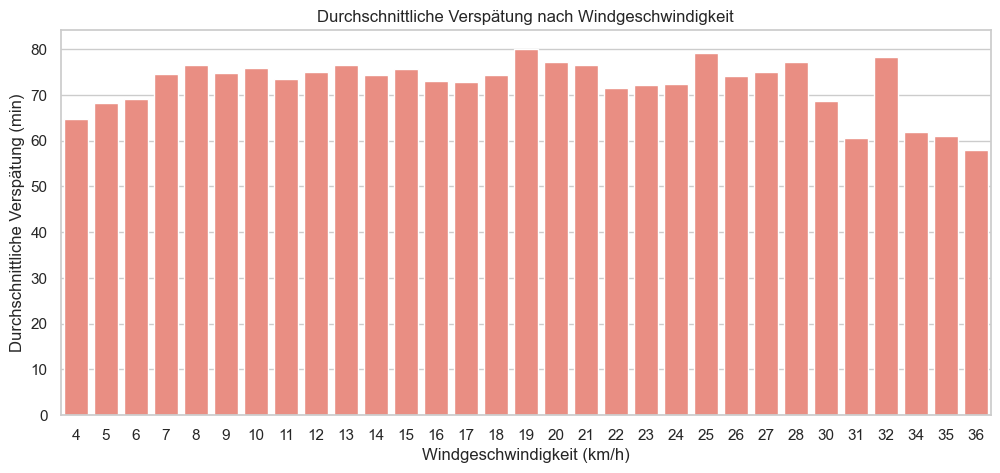

In [62]:
# 12. Analyse: Durchschnittliche Verspätung nach Windgeschwindigkeit

# NaN in 'wspd' auf 0 setzen (falls vorhanden)
df_weather_copy = df_weather.copy()
df_weather_copy['wspd'] = df_weather_copy['wspd'].fillna(0)

# Merge mit Flugdaten
df_merged_copy = pd.merge(
    df_flights,
    df_weather_copy,
    left_on='scheduled_departure',
    right_on='datetime',
    how='left'
)

# Windgeschwindigkeit auf ganze Zahlen runden
df_merged_copy['wspd_floor'] = df_merged_copy['wspd'].apply(lambda x: int(x))

# Gruppieren: Durchschnittliche Verspätung je Windgeschwindigkeit
df_wind_plot = df_merged_copy.groupby('wspd_floor')['FLT_DEP_1'].mean().reset_index()

# Visualisierung: Balkendiagramm
plt.figure(figsize=(12, 5))
sns.barplot(x='wspd_floor', y='FLT_DEP_1', data=df_wind_plot, color='salmon')
plt.xlabel("Windgeschwindigkeit (km/h)")
plt.ylabel("Durchschnittliche Verspätung (min)")
plt.title("Durchschnittliche Verspätung nach Windgeschwindigkeit")
plt.show()

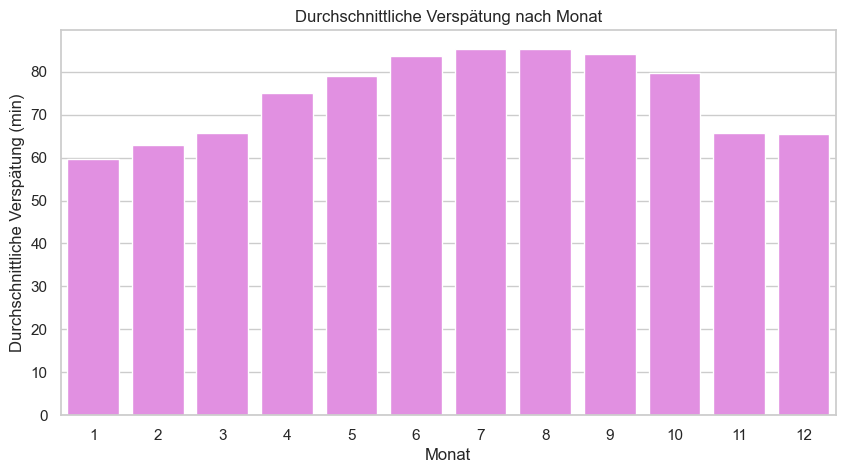

In [63]:
# 13. Analyse: Durchschnittliche Verspätung nach Monat

# Monat aus dem Abflugdatum extrahieren
df_merged_copy = df_flights.copy()
df_merged_copy['month'] = df_merged_copy['scheduled_departure'].dt.month

# Gruppieren: Durchschnittliche Verspätung je Monat
df_month_plot = df_merged_copy.groupby('month')['FLT_DEP_1'].mean().reset_index()

# Visualisierung: Balkendiagramm
plt.figure(figsize=(10, 5))
sns.barplot(x='month', y='FLT_DEP_1', data=df_month_plot, color='violet')
plt.xlabel("Monat")
plt.ylabel("Durchschnittliche Verspätung (min)")
plt.title("Durchschnittliche Verspätung nach Monat")
plt.show()

MapReduce (Aggregation) Ergebnis:
    month  avg_delay
0       1  59.717070
1       2  62.994401
2       3  65.799630
3       4  75.096601
4       5  78.898567
5       6  83.656283
6       7  85.237090
7       8  85.387084
8       9  84.099509
9      10  79.763174
10     11  65.663510
11     12  65.386720


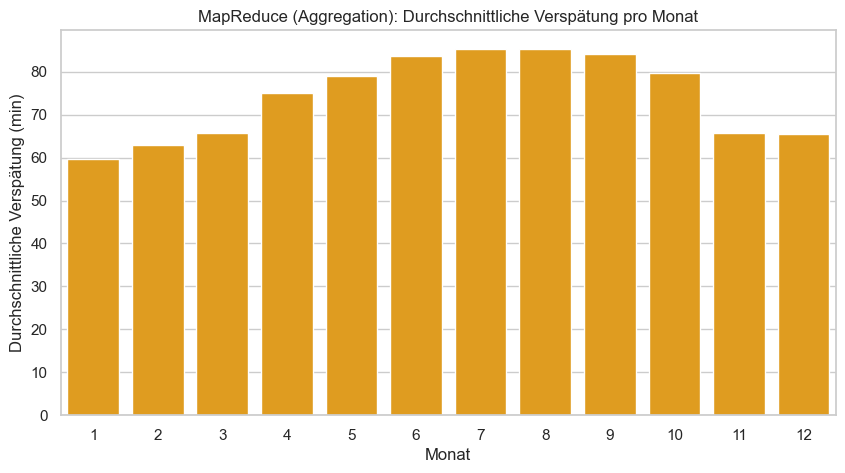

In [64]:
# 14. Analyse: Durchschnittliche Verspätung nach Monat (MapReduce)

pipeline_mapreduce = [
    {
        "$project": {
            "month": { "$month": "$scheduled_departure" },
            "delay": "$FLT_DEP_1"
        }
    },
    {
        "$group": {
            "_id": "$month",
            "avg_delay": { "$avg": "$delay" }
        }
    },
    {
        "$sort": { "_id": 1 }
    }
]

# Pipeline ausführen
result = list(flights_collection.aggregate(pipeline_mapreduce))

# In DataFrame umwandeln
df_mapreduce = pd.DataFrame(result)
df_mapreduce.rename(columns={"_id": "month"}, inplace=True)

print("MapReduce (Aggregation) Ergebnis:")
print(df_mapreduce)

# Visualisierung
plt.figure(figsize=(10,5))
sns.barplot(x="month", y="avg_delay", data=df_mapreduce, color='orange')
plt.xlabel("Monat")
plt.ylabel("Durchschnittliche Verspätung (min)")
plt.title("MapReduce (Aggregation): Durchschnittliche Verspätung pro Monat")
plt.show()

## Vergleich der Methoden

**Pandas**: einfache, schnelle Analyse für kleinere Datenmengen  

**MongoDB Aggregation (MapReduce)**: skalierbar für große Datenmengen  

**Fazit:** Die Ergebnisse sind ähnlich, jedoch ist die MongoDB-Lösung besser für Big Data geeignet.

## Big Data Kriterien (5Vs)

**Volume:**
- Aktuell kleine bis mittlere Datenmengen (CSV-Dateien, Wetterdaten).  
- Infrastruktur erlaubt aber skalierbare Verarbeitung in MongoDB → geeignet für größere Datenmengen.

**2. Velocity:**  
- Daten stammen aus historischen Flugdaten → statisch.  
- Pipeline könnte aber für Echtzeit-Daten aus API erweitert werden (z.B. Live-Wetter oder Flüge).

**3. Variety:**  
- Zwei verschiedene Datenquellen: Flugdaten (CSV), Wetterdaten (CSV/API).  
- Daten enthalten unterschiedliche Formate: Datum, Temperatur, Niederschlag, Verspätung.

**4. Veracity:**  
- Flugdaten aus offizieller Quelle, Wetterdaten aus verlässlichem Open Data API.  
- Fehlende Werte wurden bereinigt (NaN → 0 oder kategorisiert).

**5. Value:**  
- Erkenntnisse über Einfluss von Wetter auf Flugverspätungen.  
- Möglichkeit, Vorhersagen oder Optimierungen für Flughafen Wien zu entwickeln.


## 4 Levels der Datenverarbeitung

**1. Data Source**  
- Flugdaten (CSV)  
- Wetterdaten (CSV)

**2. Data Storage**  
- MongoDB als NoSQL-Datenbank  
- Vorteil: einfache Aggregation, skalierbar für große Datenmengen, Multiuser-Zugriff

**3. Data Analysis**  
- Pandas: schnelle Analyse für kleine Datenmengen  
- MongoDB Aggregation (MapReduce): skalierbare Berechnung

**4. Data Output / Visualization**  
- Balkendiagramme für Durchschnittsverspätungen nach Temperatur, Wind, Niederschlag, Monat  
- Vergleich Pandas vs. MongoDB Aggregation zeigt Funktionsweise und Skalierbarkeit

## Infrastruktur & Architektur

**Architekturübersicht:**


In [65]:
# Python Version:
import sys
print(f"Python Version: {sys.version}")

# Pandas Version:
import pandas as pd
print(f"Pandas Version: {pd.__version__}")

# Matplotlib Version:
import matplotlib
print(f"Matplotlib Version: {matplotlib.__version__}")

# Seaborn Version:
import seaborn as sns
print(f"Seaborn Version: {sns.__version__}")

# MongoDB-Version:
print(f"Matplotlib Version:") 
!mongod --version | head -n 1

Python Version: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:16:10) [GCC 11.2.0]
Pandas Version: 2.3.3
Matplotlib Version: 3.10.6
Seaborn Version: 0.13.2
Matplotlib Version:
db version v7.0.31



**Details:**
- **Python 3.13.9**
- **Pandas 2.3.3**
- **Matplotlib 3.10.6**
- **Seaborn 0.13.2**  
- **MongoDB 7.0.31** als NoSQL-Datenbank für skalierbare Speicherung  
- **Multiuser Setup:** GitHub Repository, Zugriff auf Notebook & Daten für das Team 